In [ ]:
from skimage.segmentation import mark_boundaries
import lime
from lime import lime_image
import cv2
import numpy as np

In [ ]:
def find_true_class(file_path):

    parts = file_path.split('/')

    dataset_index = parts.index('dataset')

    class_name = parts[dataset_index + 1]

    return class_name

In [ ]:

def preprocess_image(image):
    image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_NEAREST)
    image = image / 255.0  # Normalize pixel values
    return np.expand_dims(image, axis=0)

def visualize(file_path, ax, text_loc):
    test_image = cv2.imread(file_path)
    test_image = preprocess_image(test_image)

    probs = model.predict(test_image)
    pred_class = np.argmax(probs)
    pred_class = class_names[pred_class]

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        test_image[0], model.predict, top_labels=5, hide_color=0, num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )

    ax.imshow(mark_boundaries(temp, mask))
    fig.text(text_loc, 0.9, "Predicted Class: " + pred_class, fontsize=13)
    true_class = find_true_class(file_path)
    if true_class is not None:
        fig.text(text_loc, 0.86, "Actual Class: " + true_class, fontsize=13)


1/1 [==============================] - 4s 4s/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 51ms/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 39ms/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 36ms/step


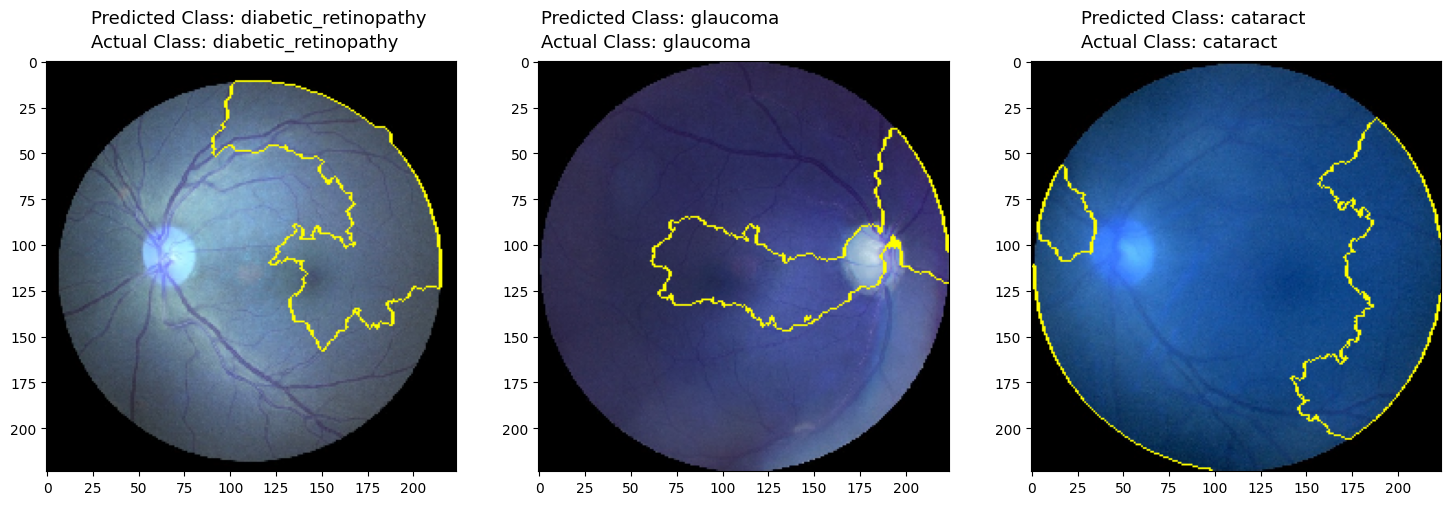

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(18,6))
visualize('dataset/diabetic_retinopathy/10003_left.jpeg',ax[0],0.15)
visualize('dataset/glaucoma/1270_right.jpg',ax[1],0.4)
visualize('dataset/cataract/1987_left.jpg',ax[2],0.7)
